In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/salary_dataset.csv')

# Оценка данных по столбцам, базовые статистики.

In [96]:
# Посмотрим на размеры датафрейма
df.shape

(6704, 9)

In [97]:
df.head()

,Unnamed: 0,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,UK,White
1,1,28.0,Female,Master's,Data Analyst,3.0,65000.0,USA,Hispanic
2,2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Canada,White
3,3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,USA,Hispanic
4,4,52.0,Male,Master's,Director,20.0,200000.0,USA,Asian


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           6704 non-null   int64  
 1   Age                  6702 non-null   float64
 2   Gender               6702 non-null   object 
 3   Education Level      6701 non-null   object 
 4   Job Title            6702 non-null   object 
 5   Years of Experience  6701 non-null   float64
 6   Salary               6699 non-null   float64
 7   Country              6704 non-null   object 
 8   Race                 6704 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 471.5+ KB


Базовые статистики:

In [99]:
df.describe().round(2)

,Unnamed: 0,Age,Years of Experience,Salary
count,6704.00,6702.00,6701.00,6699.00
mean,3351.50,33.62,8.09,115326.96
std,1935.42,7.61,6.06,52786.18
min,0.00,21.00,0.00,350.00
25%,1675.75,28.00,3.00,70000.00
50%,3351.50,32.00,7.00,115000.00
75%,5027.25,38.00,12.00,160000.00
max,6703.00,62.00,34.00,250000.00


# Подготовка данных

Посмотрим на количество пропусков в данных:

In [100]:
df.isna().sum()

,0
Unnamed: 0,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5
Country,0
Race,0


Пропусков не много и их удаление не скажется на общей картине

In [101]:
# Удаляем пропуски
df[df.isnull().any(axis=1)]
df.dropna(inplace=True)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6698 entries, 0 to 6703
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           6698 non-null   int64  
 1   Age                  6698 non-null   float64
 2   Gender               6698 non-null   object 
 3   Education Level      6698 non-null   object 
 4   Job Title            6698 non-null   object 
 5   Years of Experience  6698 non-null   float64
 6   Salary               6698 non-null   float64
 7   Country              6698 non-null   object 
 8   Race                 6698 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 523.3+ KB


Исключаем неинформативные столбцы

In [103]:
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6698 entries, 0 to 6703
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6698 non-null   float64
 1   Gender               6698 non-null   object 
 2   Education Level      6698 non-null   object 
 3   Job Title            6698 non-null   object 
 4   Years of Experience  6698 non-null   float64
 5   Salary               6698 non-null   float64
 6   Country              6698 non-null   object 
 7   Race                 6698 non-null   object 
dtypes: float64(3), object(5)
memory usage: 471.0+ KB


In [105]:
df['Gender'].value_counts()

,count
Gender,
Male,3671
Female,3013
Other,14


Видим, что количество работников, имеющих пол Other настолько мало, что можем ими пренебречь:

In [106]:
df_orth = df[df['Gender'] != 'Other']

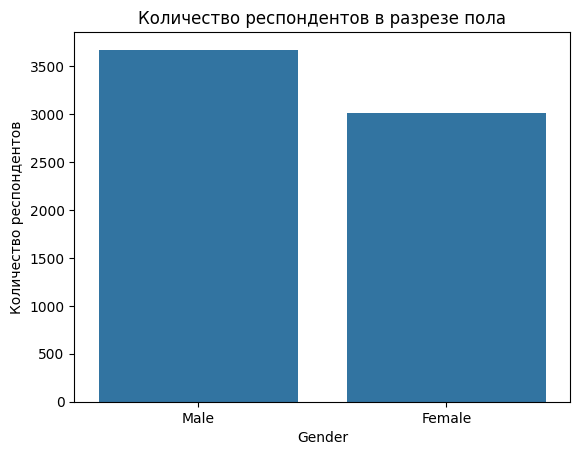

In [107]:
sns.countplot(data=df_orth, x="Gender")
plt.title("Количество респондентов в разрезе пола")
plt.ylabel("Количество респондентов")
plt.show()

In [108]:
df_orth['Education Level'].value_counts()

,count
Education Level,
Bachelor's Degree,2265
Master's Degree,1570
PhD,1368
Bachelor's,756
High School,436
Master's,288
phD,1


Объединим данные по аналогичным ученым степеням:

In [109]:
df_orth['Education Level'] = df_orth['Education Level'].replace({"Bachelor's" : "Bachelor's Degree", "Master's" : "Master's Degree", "phD" : "PhD"})
df_orth['Education Level'].value_counts()

<ipython-input-109-b110ad7ac133>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_orth['Education Level'] = df_orth['Education Level'].replace({"Bachelor's" : "Bachelor's Degree", "Master's" : "Master's Degree", "phD" : "PhD"})


,count
Education Level,
Bachelor's Degree,3021
Master's Degree,1858
PhD,1369
High School,436


In [110]:
df_orth['Job Title'].value_counts()

,count
Job Title,
Software Engineer,518
Data Scientist,453
Software Engineer Manager,376
Data Analyst,363
Senior Project Engineer,316
...,...
Junior Research Scientist,1
Senior Product Development Manager,1
Junior Social Media Specialist,1


# Выбросы

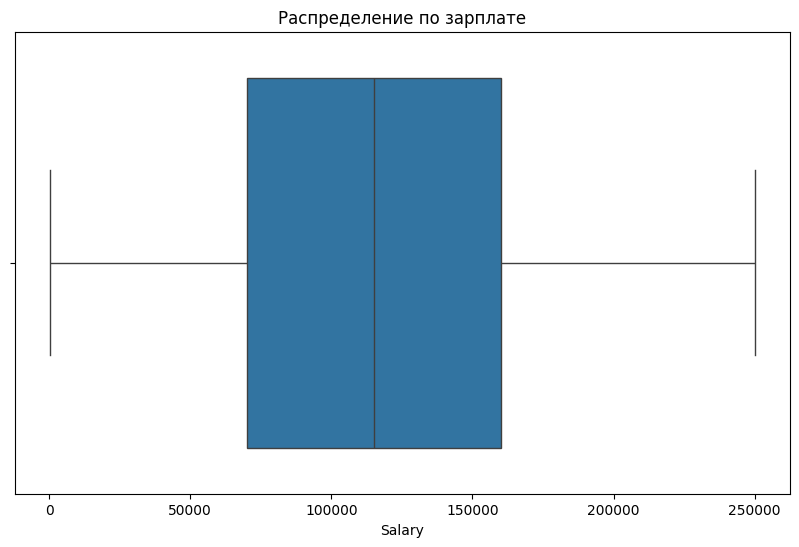

In [111]:
# Проверка на выбросы по зарплате
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_orth['Salary'])
plt.title('Распределение по зарплате')
plt.show()

In [112]:
# Удаляем выбросы
Q1 = df_orth['Salary'].quantile(0.25)
Q3 = df_orth['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

df_orth_no_outliers = df_orth[(df_orth['Salary'] >= lower_bound) & (df_orth['Salary'] <= upper_bound)]
print(f"Removed {df_orth.shape[0] - df_orth_no_outliers.shape[0]} outliers")

Removed 0 outliers


После удаления пропусков выбросы отсутствуют.

In [113]:
# Далее будем работать с копией "чистого" датасета
df_clean = df_orth_no_outliers.copy()

# Гипотеза 1. С опытом работы уровень зарплаты растет.

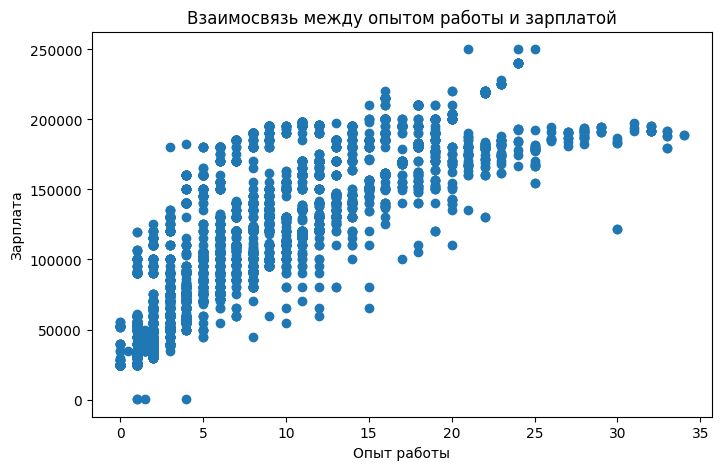

In [114]:
plt.figure(figsize=[8,5])
plt.scatter(data=df_clean, x="Years of Experience", y="Salary")
plt.title("Взаимосвязь между опытом работы и зарплатой")
plt.ylabel("Зарплата")
plt.xlabel("Опыт работы")
plt.show()

Действительно, если интерполировать - уровень зарплаты растет по мере увеличения стажа, и в какой то момент, когда опыт уже большой, перестает расти.

# Гипотеза 2. Мужчинам платят больше, чем женщинам.

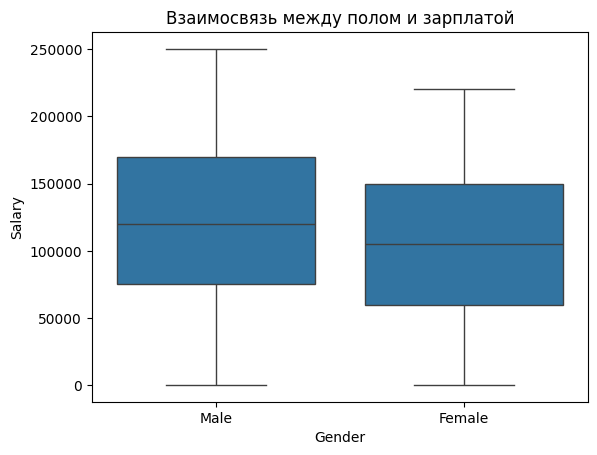

In [115]:
sns.boxplot(data=df_clean, x='Gender', y='Salary')
plt.title("Взаимосвязь между полом и зарплатой");
plt.show()

Действительно, уровень средней и максимальной зарплат у мужчин выше, чем у женщин, но эта разница не слишком велика.

# Гипотеза 3. Чем сотрудник старше, тем выше уровень его зарплаты.

<Axes: xlabel='Age Group', ylabel='Salary'>

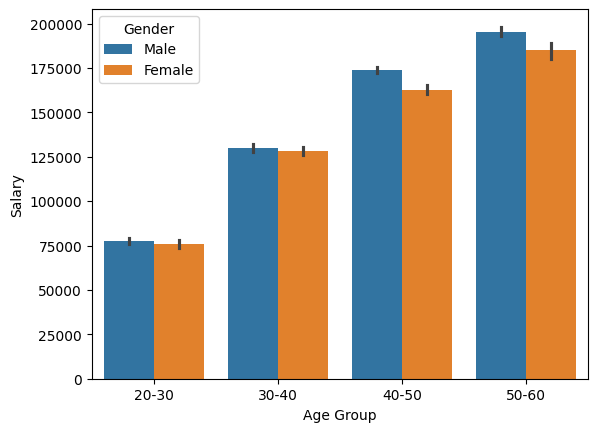

In [116]:
df_clean['Age Group'] = pd.cut(df_clean['Age'], bins=[20, 30, 40, 50, 60], labels=['20-30', '30-40', '40-50', '50-60'])
sns.barplot(x='Age Group', y='Salary', hue='Gender', data=df_clean)

Действительно, чем старше сотрудник, тем выше его зарплата, опять же в силу стажа.
Что интересно, разница между уровнем дохода у мужчин и женщин с возрастом становится больше.

# Гипотеза 4. Чем выше уровень образования, тем выше зарплата.

Посмотрим сначала на распределение по уровню образования:

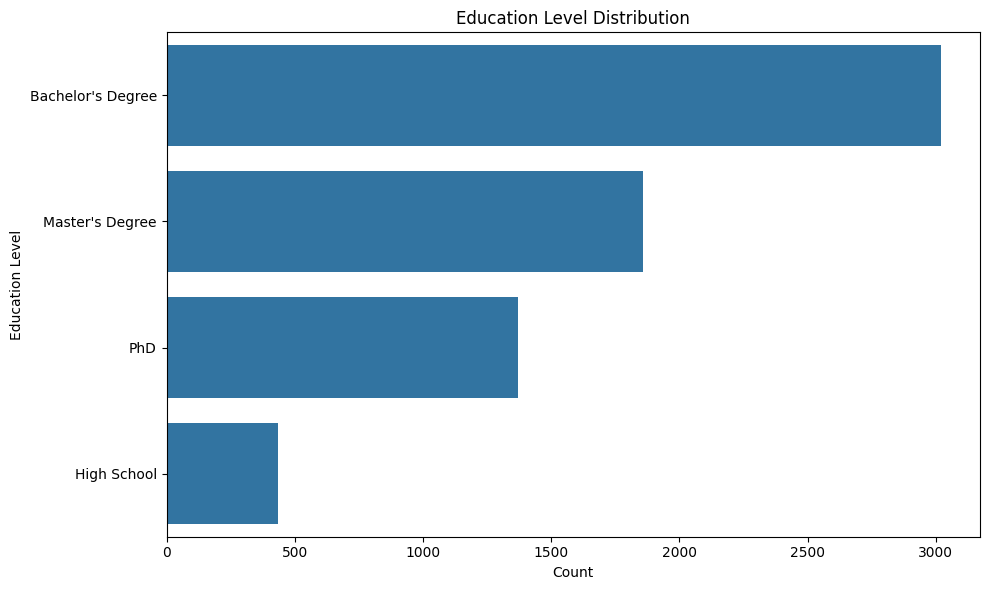

In [117]:
edu_counts = df_clean['Education Level'].value_counts()
plt.figure(figsize=(10, 6))
sns.countplot(y='Education Level', data=df_clean, order=edu_counts.index)
plt.title('Education Level Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

<Axes: xlabel='Education Level', ylabel='Salary'>

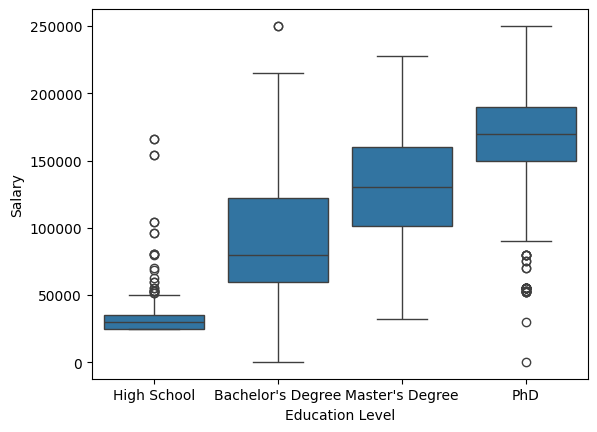

In [118]:
sns.boxplot(x='Education Level', y='Salary', data=df_clean, order=["High School", "Bachelor's Degree", "Master's Degree","PhD"])

Сотрудники с более высоким уровнем образования имеют более высокую зарплату, что вполне логично.

Посмотрим на зависимость средней зарплаты от уровня образования в разрезе пола:

([0, 1, 2, 3],
 [Text(0, 0, 'High School'),
  Text(1, 0, "Bachelor's Degree"),
  Text(2, 0, "Master's Degree"),
  Text(3, 0, 'PhD')])

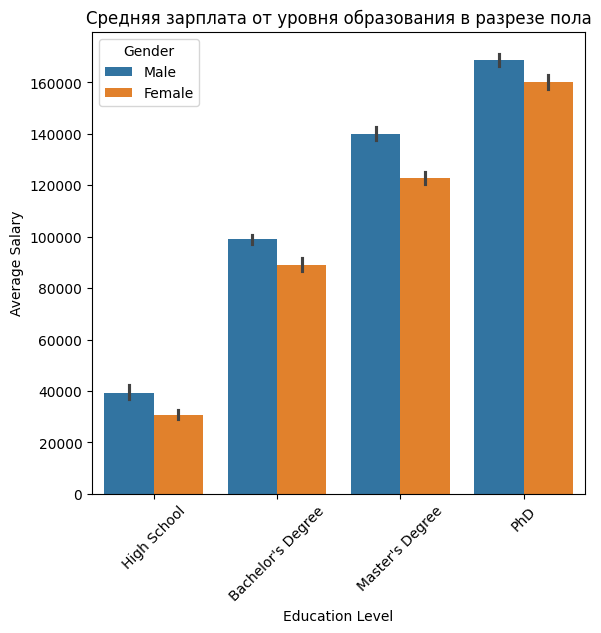

In [120]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Education Level', y='Salary', hue='Gender', data=df_clean, order=["High School", "Bachelor's Degree", "Master's Degree","PhD"])
plt.title('Средняя зарплата от уровня образования в разрезе пола')
plt.xlabel('Education Level')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)

Разница в зарплате у мужчин и женщин характерна для всех ученых степеней.

# Корреляционнй анализ

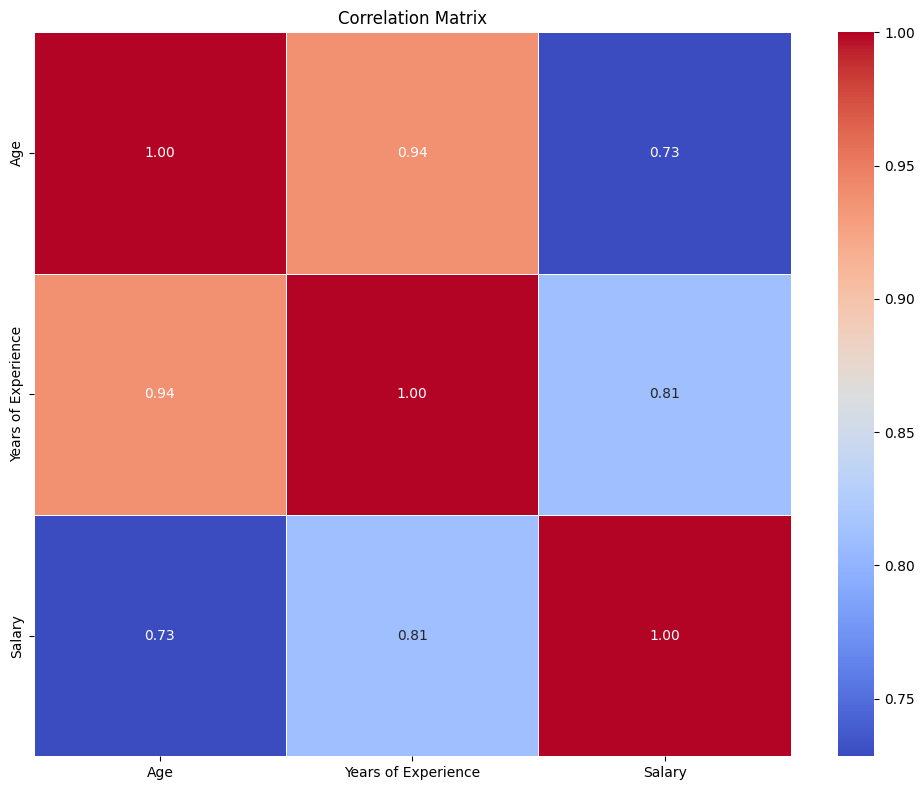

In [122]:
numeric_df = df_clean[['Age', 'Years of Experience', 'Salary']]
correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


Сильная корреляция между возрастом и стажем, что вполне ожидаемо.
Корреляция межу зарплатой и стажем сильнее, чем между зарплатой и возрастом.

In [124]:
!pip install phik
import phik
from phik.report import plot_correlation_matrix

In [126]:
phik_overview = df_clean.phik_matrix(interval_cols=['Age', 'Years of Experience', 'Salary'])
phik_overview

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race,Age Group
Age,1.000000,0.254605,0.592824,0.809610,0.900794,0.753203,0.000000,0.000000,0.959363
Gender,0.254605,1.000000,0.272188,0.545828,0.176016,0.243200,0.000000,0.000000,0.207334
Education Level,0.592824,0.272188,1.000000,0.938926,0.625996,0.732353,0.009176,0.007223,0.719641
Job Title,0.809610,0.545828,0.938926,1.000000,0.787787,0.892065,0.000000,0.062432,0.822133
Years of Experience,0.900794,0.176016,0.625996,0.787787,1.000000,0.827547,0.044702,0.033049,0.878541
Salary,0.753203,0.243200,0.732353,0.892065,0.827547,1.000000,0.093777,0.067361,0.676145
Country,0.000000,0.000000,0.009176,0.000000,0.044702,0.093777,1.000000,0.950641,0.019935
Race,0.000000,0.000000,0.007223,0.062432,0.033049,0.067361,0.950641,1.000000,0.000000
Age Group,0.959363,0.207334,0.719641,0.822133,0.878541,0.676145,0.019935,0.000000,1.000000


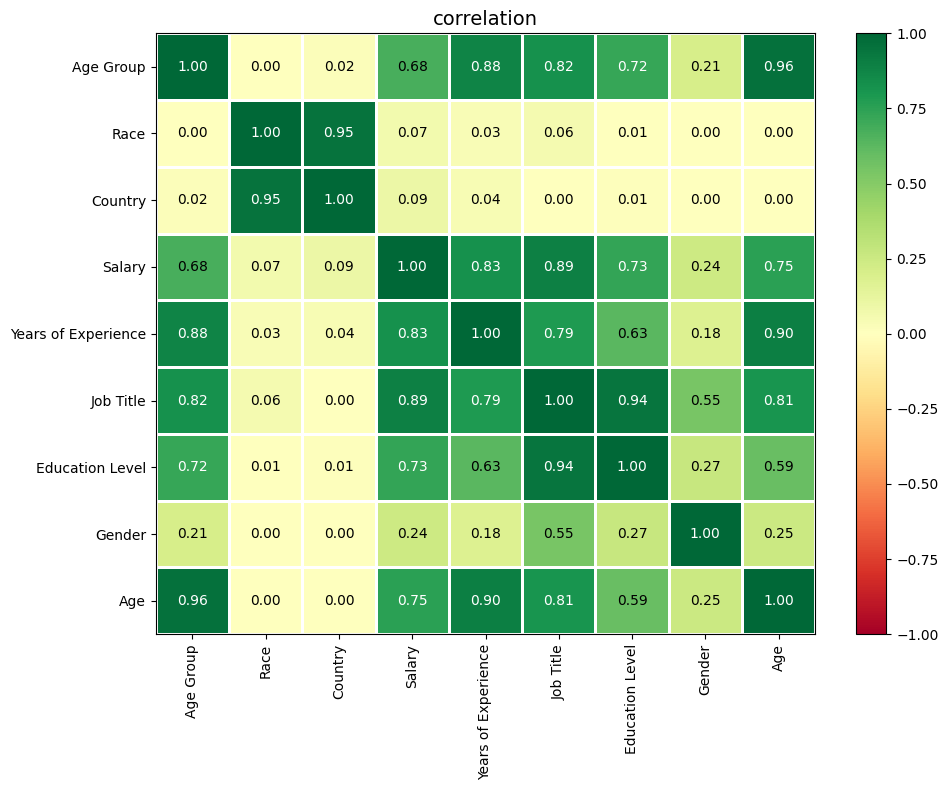

In [127]:
plot_correlation_matrix(phik_overview.values, x_labels=phik_overview.columns, y_labels=phik_overview.index, figsize=(10, 8))